# Bellabeat Case Study

---

## 1. Introduction

Bellabeat is a high-tech company that manufactures health-focused smart products designed primarily for women. The company collects data through wearable devices that track physical activity, sleep patterns, and other health-related metrics.

The objective of this analysis is to explore Fitbit fitness tracker data in order to identify behavioral patterns related to physical activity, sleep, and heart rate. By understanding how users interact with these devices, we can extract insights that could help improve product development and marketing strategies.

This notebook focuses on cleaning the dataset, preparing the data for analysis, and performing exploratory data analysis to identify relevant health and activity trends.

---

## 2. Dataset Description

The dataset used in this analysis comes from Fitbit fitness tracker data available on Kaggle.

It contains multiple CSV files with information collected from wearable devices, including:

- Daily physical activity
- Sleep tracking
- Weight logs
- Heart rate measurements

Key datasets used in this analysis include:

- **dailyActivity_merged.csv** – daily step counts, calories burned, and activity intensity levels.
- **sleepDay_merged.csv** – sleep duration and sleep sessions.
- **weightLogInfo_merged.csv** – weight tracking information.
- **heartrate_seconds_merged.csv** – heart rate measurements recorded at second-level intervals.

These datasets allow us to explore user behavior related to activity levels, sleep habits, and cardiovascular indicators.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets (relative path from notebooks/)
daily_activity = pd.read_csv("../data/raw/dailyActivity_merged.csv")
sleep_log = pd.read_csv("../data/raw/sleepDay_merged.csv")
weight_log = pd.read_csv("../data/raw/weightLogInfo_merged.csv")
heart_rate = pd.read_csv("../data/raw/heartrate_seconds_merged.csv")

In [3]:
# check data types
daily_activity.info()
sleep_log.info()
weight_log.info()
heart_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

## 3. Data Cleaning

Before performing any analysis, it is necessary to clean the dataset to ensure data consistency and reliability.

The cleaning process includes:

- Removing duplicate records
- Verifying data integrity
- Ensuring that each dataset contains unique observations

Cleaning the data is an essential step because duplicated or inconsistent records could lead to incorrect analytical results.

In [12]:
# check missing values
daily_activity.isnull().sum()
sleep_log.isnull().sum()
weight_log.isnull().sum()
heart_rate.isnull().sum()

Id          0
Time        0
Value       0
DateTime    0
Date        0
dtype: int64

---

### Removing Duplicate Records

Before performing the analysis, it was necessary to ensure data consistency and integrity. Duplicate records can introduce bias in summary statistics and distort behavioral trends.

Using the `drop_duplicates()` function from the `pandas` library, duplicate observations were removed from each dataset. This step guarantees that each activity log, sleep entry, weight record, and heart rate measurement is counted only once.

By cleaning duplicate entries at this stage, the analysis is based on accurate and reliable observations, preventing inflated activity counts or misleading aggregation results.

In [21]:
# check duplicated rows
daily_activity.duplicated().sum()
sleep_log.duplicated().sum()
weight_log.duplicated().sum()
heart_rate.duplicated().sum()

np.int64(0)

In [22]:
daily_activity = daily_activity.drop_duplicates()
sleep_log = sleep_log.drop_duplicates()
weight_log = weight_log.drop_duplicates()
heart_rate = heart_rate.drop_duplicates()

## 4. Data Preparation

After cleaning the dataset, the next step is preparing the data for analysis.

This stage includes:

- Converting date columns into proper datetime formats
- Creating new time-related variables (day, month, etc.)
- Structuring the data to allow aggregation and time-based analysis

Proper data preparation ensures that the dataset can be analyzed efficiently and that temporal patterns can be correctly identified.

---

### Converting Date Columns

To ensure accurate time-based analysis, all date-related fields were converted to proper datetime format using `pandas.to_datetime()`.

Several columns were originally stored as strings, and in some cases included both date and time information. To standardize the data and enable grouping by day, the relevant date portion was extracted when necessary before conversion.

By transforming these columns into datetime objects, the datasets become suitable for chronological operations such as filtering by date, aggregating by day, and comparing user behavior over time.

This step is critical for performing reliable temporal analysis and generating meaningful daily and monthly summaries.

---

In [23]:
# daily activity
daily_activity["ActivityDate"] = pd.to_datetime(
    daily_activity["ActivityDate"],
    format="%m/%d/%Y"
)

# sleep log
sleep_log["SleepDay"] = pd.to_datetime(
    sleep_log["SleepDay"],
    format="%m/%d/%Y %I:%M:%S %p"
)

# weight log
weight_log["Date"] = pd.to_datetime(
    weight_log["Date"],
    format="%m/%d/%Y %I:%M:%S %p"
)

# heart rate
heart_rate["DateTime"] = pd.to_datetime(
    heart_rate["Time"],
    format="%m/%d/%Y %I:%M:%S %p"
)

heart_rate["Date"] = heart_rate["DateTime"].dt.date

## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to investigate patterns, detect anomalies, and better understand the relationships within the dataset.

In this section, we analyze heart rate metrics by aggregating the data at different levels, such as daily and monthly summaries. These aggregations allow us to observe patterns in user cardiovascular activity and identify differences between resting and active heart rate ranges.

Visualization techniques such as boxplots are used to compare distributions and highlight variability in heart rate values.

---

### Heart Rate Analysis (Daily and Monthly Aggregation)

The `heartrate_seconds_merged.csv` dataset contains more than two million heart rate measurements recorded every five seconds. In order to make the dataset suitable for analysis and comparison, the data was first aggregated at a daily level.

Using `groupby()` and aggregate functions (`min`, `mean`, and `max`), heart rate measurements were summarized per user per day. This transformation significantly reduced dimensionality while preserving representative cardiovascular metrics such as resting trends (minimum), overall daily average, and peak effort (maximum).

After obtaining daily summaries, the data was further aggregated at the user level to generate monthly statistics. This second level of aggregation enables comparisons between users and helps identify behavioral differences between more active and more sedentary individuals.

By structuring the analysis in this way—first at a granular daily level and then at a higher user-level summary—the project balances data reduction with meaningful insight extraction.

---

In [24]:
heart_rate_by_day = (
    heart_rate
    .groupby(["Id", "Date"])["Value"]
    .agg(["min", "mean", "max"])
    .reset_index()
)

heart_rate_by_day.columns = ["Id", "Date", "min_heart_rate", "mean_heart_rate", "max_heart_rate"]

In [25]:
heart_rate_by_month = (
    heart_rate_by_day
    .groupby("Id")
    .agg({
        "min_heart_rate": "min",
        "mean_heart_rate": "mean",
        "max_heart_rate": "max"
    })
    .reset_index()
)

---

### Share

The best way to share the findings is by using images, the best way to compare differences betweendata sets is using  [box plots](https://www.wellbeingatschool.org.nz/information-sheet/understanding-and-interpreting-box-plots#:~:text=The%20median%20(middle%20quartile)%20marks,value%20and%20half%20are%20less.&text=The%20middle%20%E2%80%9Cbox%E2%80%9D%20represents%20the,of%20scores%20for%20the%20group.), the following graphs represent the range of heart rate values of all 14 users during any given day, Interpretation of heart rate values can be complex if we are not familiar with health sciences, fortunately, thanks to the Harvard Health Publishing we can learn about [what our heart rate is telling us](https://www.health.harvard.edu/heart-health/what-your-heart-rate-is-telling-you#:~:text=Your%20resting%20heart%20rate&text=For%20most%20healthy%20adult%20women,to%20100%20beats%20per%20minute.). The next graph is generated using the `heart_rate_by_day` dataframe.

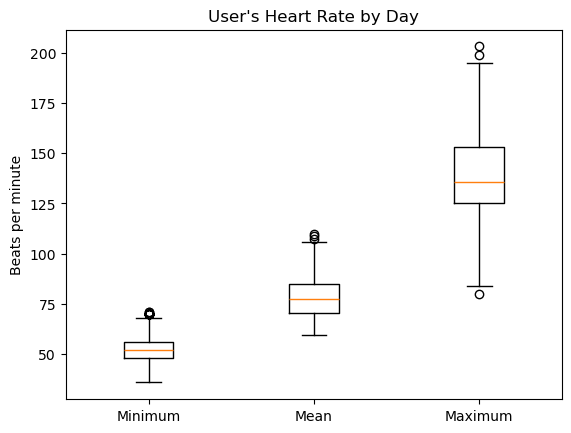

In [26]:
plt.figure()
plt.boxplot([
    heart_rate_by_day["min_heart_rate"],
    heart_rate_by_day["mean_heart_rate"],
    heart_rate_by_day["max_heart_rate"]
])

plt.title("User's Heart Rate by Day")
plt.xticks([1,2,3], ["Minimum", "Mean", "Maximum"])
plt.ylabel("Beats per minute")
plt.show()

After reading the last blog we can see that the minimum values represent resting heart rate and the maximum values correspond to high activity. I have noticed that some of the maximum heart rate values are close to the range of average values, perhaps this is due to the lack of physical activity on those days. The next graph is the same has the upper one but using only the most representative data during the month wich are ccontain in the `heart_rate_by_month` dataframe.

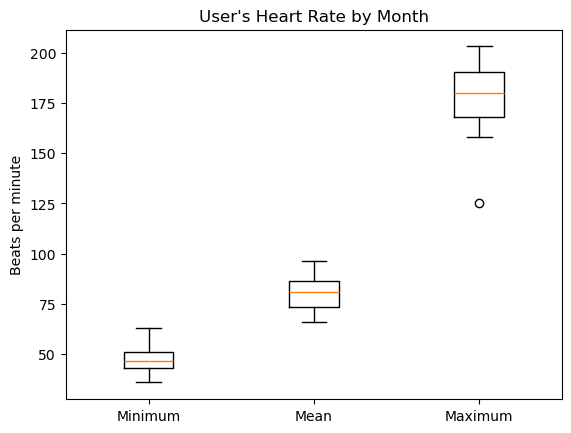

In [27]:
plt.figure()
plt.boxplot([
    heart_rate_by_month["min_heart_rate"],
    heart_rate_by_month["mean_heart_rate"],
    heart_rate_by_month["max_heart_rate"]
])

plt.title("User's Heart Rate by Month")
plt.xticks([1,2,3], ["Minimum", "Mean", "Maximum"])
plt.ylabel("Beats per minute")
plt.show()

### Heart Rate Conlusion

As we can see from [Harvard Health Publishing](https://www.health.harvard.edu/heart-health/what-your-heart-rate-is-telling-you#:~:text=Your%20resting%20heart%20rate&text=For%20most%20healthy%20adult%20women,to%20100%20beats%20per%20minute.)  a normal resting heart rate for adults ranges from 60 to 100 beats per minute. Generally, a **lower resting heart rate** implies **more efficient heart** function and **better cardiovascular fitness**. One way to calculate the maximum heart rate is to subtract age from 220. In the data **there is no information on the age and sex of the users** so I cannot determine the causes of the difference in maximum heart rate, **the lower value in the maximum heart rate boxplot could correspond to a sedentary user or an older one**.
In the following graph I have tried to show the usefulness that this type of diagrams can have, the idea is to compare the heart rate of a fairly active user versus a sedentary one. The more active user will be the one with the maximum heart rate, while the sedentary user will select the minimum value in the maximum heart rate field.

In [28]:
active_user = heart_rate_by_month.loc[
    heart_rate_by_month["max_heart_rate"].idxmax()
]

sedentary_user = heart_rate_by_month.loc[
    heart_rate_by_month["max_heart_rate"].idxmin()
]

active_user_data = heart_rate[heart_rate["Id"] == active_user["Id"]]
sedentary_user_data = heart_rate[heart_rate["Id"] == sedentary_user["Id"]]

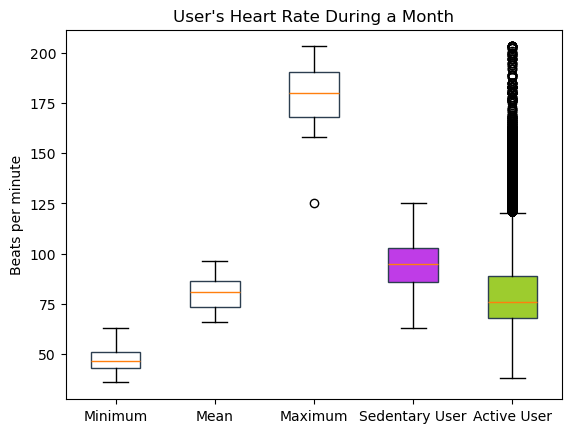

In [29]:
bp = plt.boxplot([
    heart_rate_by_month["min_heart_rate"],
    heart_rate_by_month["mean_heart_rate"],
    heart_rate_by_month["max_heart_rate"],
    sedentary_user_data["Value"],
    active_user_data["Value"]
], patch_artist=True)

# 2. Definimos los colores para cada una de las 5 cajas
# Usaremos un color neutro para los primeros 3 y colores contrastantes para los últimos 2
colors = ['#FFFFFF', '#FFFFFF', '#FFFFFF', "#BF3CE7", "#9DCC2E"] 

# 3. Iteramos sobre las cajas (patches) y aplicamos los colores
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    # Opcional: cambiar el color del borde a uno más oscuro
    patch.set_edgecolor('#2C3E50')

plt.title("User's Heart Rate During a Month")
plt.xticks([1, 2, 3, 4, 5], [
    "Minimum",
    "Mean",
    "Maximum",
    "Sedentary User",
    "Active User"
])

plt.ylabel("Beats per minute")
plt.show()

## 7. Business Recommendations

Based on the analysis of Fitbit activity data, several insights can help inform business strategies for companies like Bellabeat:

- Users with higher heart rate variability often show higher activity levels, indicating engagement with fitness-related features.
- Monitoring resting heart rate can provide valuable health indicators that users may find meaningful for long-term health tracking.
- Personalized insights based on activity and heart rate data could improve user engagement and retention.

Bellabeat could leverage these insights to develop features that encourage healthier habits, provide personalized feedback, and enhance the overall value of their wearable devices.